In [1]:
# =========================
# Cell 0 — Install & Imports
# =========================
!pip -q install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip -q install datasets transformers accelerate rdkit-pypi pandas numpy tqdm

import os, json, random, time
from pathlib import Path
from typing import List, Dict

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

import torch
from torch.utils.data import Dataset as TorchDataset

from datasets import load_dataset
from rdkit import Chem
from rdkit.Chem import Descriptors

from transformers import (
    GPT2Config, GPT2LMHeadModel,
    Trainer, TrainingArguments,
    set_seed
)

print("Setup complete. Torch CUDA:", torch.cuda.is_available())


2025-09-19 02:13:47.191917: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /opt/sw/other/apps/cudnn/cudnn-linux-x86_64-9.6.0.74_cuda12-archive/lib:/opt/sw/other/apps/cuda/12.6.3/lib64:/opt/sw/spack/apps/linux-rhel8-x86_64_v2/gcc-10.3.0/openmpi-4.1.2-4a/lib:/opt/sw/spack/apps/linux-rhel8-x86_64_v2/gcc-10.3.0/python-3.9.9-jh/lib:/opt/sw/spack/apps/linux-rhel8-x86_64_v2/gcc-10.3.0/tcl-8.6.11-d4/lib:/opt/sw/spack/apps/linux-rhel8-x86_64_v2/gcc-10.3.0/sqlite-3.37.1-6s/lib:/opt/sw/spack/apps/linux-rhel8-x86_64_v2/gcc-10.3.0/zlib-1.2.11-2y/lib:/opt/sw/spack/apps/linux-rhel8-x86_64_v2/gcc-9.3.0/gcc-10.3.0-ya/lib64:/opt/sw/spack/apps/linux-rhel8-x86_64_v2/gcc-9.3.0/gcc-10.3.0-ya/lib
2025-09-19 02:13:47.191955: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on 

Setup complete. Torch CUDA: True


In [2]:
# =========================
# Cell 1 — Config, Seeds, Paths
# =========================
SEED = 1337
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

RUN_DIR = Path("runs/m1_chem_tok_v1"); RUN_DIR.mkdir(parents=True, exist_ok=True)

CONFIG = {
    "seed": SEED,
    "max_len_cap": 256,
    "ctx_len": 256,
    "model_dims": {"n_layer": 8, "n_head": 8, "n_embd": 512},
    "train": {
        "epochs": 5,
        "lr": 3e-4,
        "weight_decay": 0.05,
        "warmup_steps": 5000,
        "per_device_batch": 32,
        "grad_accum": 4,
        "fp16": True,
        "save_steps": 2000,
        "logging_steps": 200
    },
    "sampling": {"n": 5000, "top_p": 0.95, "temperature": 1.0, "max_length": 128},
    "safety": {
        "skip_train_if_model_exists": True,  # if a final model exists, don't retrain
        "auto_resume_from_last_ckpt": True   # resume if checkpoints exist
    }
}
with open(RUN_DIR / "config.json", "w") as f: json.dump(CONFIG, f, indent=2)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Config saved ->", RUN_DIR / "config.json", "| Device:", DEVICE)


Config saved -> runs/m1_chem_tok_v1/config.json | Device: cuda


In [3]:
# =========================
# Cell 2 — Load MOSES & Clean
# =========================
# Idempotent: if cached parquet exists, reuse.
clean_path = RUN_DIR / "train_clean.parquet"
if clean_path.exists():
    train_df = pd.read_parquet(clean_path)
    print("Loaded cached cleaned data:", clean_path, "| n =", len(train_df))
else:
    ds = load_dataset("katielink/moses")
    train_split = ds["train"]
    cols = list(train_split.features.keys())
    cand = [c for c in cols if c.lower() == "smiles"]
    assert cand, f"No SMILES column found in {cols}"
    SMI_COL = cand[0]
    smiles_raw = train_split[SMI_COL]
    print(f"Raw count: {len(smiles_raw):,}")

    def clean_smiles(s: str):
        if not isinstance(s, str): return None
        try:
            m = Chem.MolFromSmiles(s, sanitize=True)
            if m is None: return None
            return Chem.MolToSmiles(m, isomericSmiles=True, canonical=True)
        except Exception:
            return None

    smiles_can = []
    drop = 0
    for s in tqdm(smiles_raw, desc="Sanitizing"):
        cs = clean_smiles(s)
        if cs is None:
            drop += 1
        else:
            smiles_can.append(cs)

    smiles_can = pd.unique(pd.Series(smiles_can)).tolist()
    train_df = pd.DataFrame({"smiles": smiles_can})
    train_df.to_parquet(clean_path, index=False)
    print(f"Kept: {len(train_df):,} | Dropped: {drop:,} | Saved -> {clean_path}")

# quick stats
lens = train_df["smiles"].str.len()
print(lens.describe(percentiles=[.5, .9, .95, .99]))


Loaded cached cleaned data: runs/m1_chem_tok_v1/train_clean.parquet | n = 1584663
count    1.584663e+06
mean     3.585848e+01
std      4.580560e+00
min      1.500000e+01
50%      3.600000e+01
90%      4.200000e+01
95%      4.300000e+01
99%      4.600000e+01
max      5.700000e+01
Name: smiles, dtype: float64


In [4]:
# =========================
# Cell 3 — Chem-aware Tokenizer (build/save)
# =========================
from typing import List, Dict
import re, json

chem_tok_path = RUN_DIR / "chem_tokenizer.json"

BRACKET_RE = re.compile(r"\[[^\[\]]+\]")      # [NH+], [C@H], [O-], isotopes, etc.
RING2_RE   = re.compile(r"%\d{2}")            # %10, %11 ...
TWO_LETTER = {"Cl","Br"}                      # never split
BONDS      = set(list("=#:-/\\."))            # bonds/aromatic markers
BRANCHES   = {"(",")"}
DIGITS     = set(list("0123456789"))
AROMATICS  = set(list("bcno sp".replace(" ","")))  # c n o s p
ELEMENTS   = set(list("BCNOPFISH"))           # common uppercase elements

def chem_tokenize(smiles: str) -> List[str]:
    """Greedy left-to-right tokenizer preserving chemistry-relevant units."""
    out = []
    i, L = 0, len(smiles)
    while i < L:
        ch = smiles[i]

        # 1) Bracketed atom (highest priority)
        if ch == "[":
            m = BRACKET_RE.match(smiles, i)
            if m:
                out.append(m.group(0))
                i = m.end()
                continue

        # 2) Two-digit ring closure like %10
        if ch == "%" and i+2 < L and smiles[i+1:i+3].isdigit():
            out.append(smiles[i:i+3])  # "%10"
            i += 3
            continue

        # 3) Two-letter atoms (Cl, Br)
        if i+1 < L and smiles[i:i+2] in TWO_LETTER:
            out.append(smiles[i:i+2])
            i += 2
            continue

        # 4) Single-char categories
        if ch in BRANCHES or ch in BONDS or ch in DIGITS or ch in AROMATICS or ch in ELEMENTS:
            out.append(ch)
            i += 1
            continue

        # 5) Fallback: keep as single char (rare symbols)
        out.append(ch)
        i += 1

    return out

# Build vocab from training set
if chem_tok_path.exists():
    with open(chem_tok_path) as f:
        chem_tok_info = json.load(f)
    print("Loaded existing chem tokenizer ->", chem_tok_path)
else:
    SPECIALS = ["<pad>", "<bos>", "<eos>", "<unk>"]
    freq = {}
    lengths = []
    for s in tqdm(train_df["smiles"], desc="Tokenizing (build vocab)"):
        toks = chem_tokenize(s)
        lengths.append(len(toks))
        for t in toks:
            freq[t] = freq.get(t, 0) + 1

    tokens = SPECIALS + sorted(freq.keys())
    stoi = {t:i for i,t in enumerate(tokens)}
    itos = tokens

    # p99 token length + buffer, capped by config
    p99_tok = int(np.percentile(lengths, 99))
    MAX_LEN = min(CONFIG["max_len_cap"], max(32, p99_tok + 8))

    chem_tok_info = {
        "itos": itos,
        "stoi": stoi,
        "pad_token": "<pad>",
        "bos_token": "<bos>",
        "eos_token": "<eos>",
        "unk_token": "<unk>",
        "max_length": MAX_LEN
    }
    with open(chem_tok_path, "w") as f:
        json.dump(chem_tok_info, f, indent=2)
    print("Saved chem tokenizer ->", chem_tok_path, "| Vocab size:", len(itos), "| MAX_LEN:", MAX_LEN)

# Tokenizer class (token-level)
class ChemTokenizer:
    def __init__(self, info: Dict):
        self.itos = info["itos"]; self.stoi = info["stoi"]
        self.pad_token = info["pad_token"]; self.bos_token = info["bos_token"]
        self.eos_token = info["eos_token"]; self.unk_token = info["unk_token"]
        self.pad_token_id = self.stoi[self.pad_token]
        self.bos_token_id = self.stoi[self.bos_token]
        self.eos_token_id = self.stoi[self.eos_token]
        self.unk_token_id = self.stoi[self.unk_token]
        self.vocab_size = len(self.itos)
        self.max_length = max(32, int(info.get("max_length", 128)))

    def encode(self, text: str):
        toks = chem_tokenize(text if isinstance(text, str) else "")
        ids_mid = [self.stoi.get(t, self.unk_token_id) for t in toks][: self.max_length - 2]
        ids = [self.bos_token_id] + ids_mid + [self.eos_token_id]
        pad_len = self.max_length - len(ids)
        if pad_len > 0:
            ids += [self.pad_token_id] * pad_len
        attn = [1] * (len(ids) - pad_len) + [0] * max(0, pad_len)
        return {"input_ids": ids, "attention_mask": attn}

    def decode(self, ids: List[int], skip_special_tokens=True):
        toks = []
        for i in ids:
            if skip_special_tokens and i in (self.pad_token_id, self.bos_token_id, self.eos_token_id):
                continue
            if 0 <= i < self.vocab_size:
                toks.append(self.itos[i])
        # join tokens into a SMILES string
        return "".join(toks)

ctok = ChemTokenizer(chem_tok_info)
print("ChemTokenizer | Vocab:", ctok.vocab_size, "| MAX_LEN:", ctok.max_length)


Loaded existing chem tokenizer -> runs/m1_chem_tok_v1/chem_tokenizer.json
ChemTokenizer | Vocab: 27 | MAX_LEN: 53


In [5]:
# =========================
# Cell 4 — Dataset (chem tokens + randomized SMILES)
# =========================
from rdkit.Chem import MolToSmiles

CONFIG["train"]["smiles_randomize_prob"] = CONFIG["train"].get("smiles_randomize_prob", 0.7)

def randomize_smiles(can_smi: str) -> str:
    m = Chem.MolFromSmiles(can_smi)
    if m is None: return can_smi
    return MolToSmiles(m, isomericSmiles=True, canonical=False, doRandom=True)

class SmilesTokenDataset(TorchDataset):
    def __init__(self, df: pd.DataFrame, tokenizer: ChemTokenizer, rand_prob: float = 0.7):
        self.df = df.reset_index(drop=True)
        self.tok = tokenizer
        self.rand_prob = rand_prob

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        s = self.df.iloc[idx]["smiles"]  # canonical source
        if random.random() < self.rand_prob:
            s = randomize_smiles(s)
        enc = self.tok.encode(s)
        input_ids = torch.tensor(enc["input_ids"], dtype=torch.long)
        attention_mask = torch.tensor(enc["attention_mask"], dtype=torch.long)
        labels = input_ids.clone()
        labels[labels == self.tok.pad_token_id] = -100
        return {"input_ids": input_ids, "attention_mask": attention_mask, "labels": labels}

def causal_collate(batch):
    # already has labels; just stack
    keys = batch[0].keys()
    return {k: torch.stack([b[k] for b in batch]) for k in keys}

train_ds_torch = SmilesTokenDataset(train_df, ctok, rand_prob=CONFIG["train"]["smiles_randomize_prob"])
len(train_ds_torch)


1584663

In [6]:
# =========================
# Cell 4b — Scaffold split (train/val) and torch datasets
# =========================
from rdkit.Chem.Scaffolds import MurckoScaffold

def murcko_scaffold(smi: str) -> str:
    m = Chem.MolFromSmiles(smi)
    if m is None: return ""
    core = MurckoScaffold.GetScaffoldForMol(m)
    return Chem.MolToSmiles(core, isomericSmiles=True, canonical=True)

# compute scaffolds (cached alongside parquet if you like)
if "scaffold" not in train_df.columns:
    train_df["scaffold"] = [murcko_scaffold(s) for s in tqdm(train_df["smiles"], desc="Scaffolds")]

# group by scaffold and make a deterministic split by scaffold buckets
rng = np.random.default_rng(1337)
scaff2idxs = {}
for i, scaf in enumerate(train_df["scaffold"]):
    scaff2idxs.setdefault(scaf, []).append(i)

all_scaff = list(scaff2idxs.keys())
rng.shuffle(all_scaff)

val_target = int(0.05 * len(train_df))  # ~5%
val_idxs, n = [], 0
for scaf in all_scaff:
    idxs = scaff2idxs[scaf]
    if n < val_target:
        val_idxs.extend(idxs)
        n += len(idxs)

mask = np.zeros(len(train_df), dtype=bool)
mask[val_idxs] = True
df_val  = train_df[mask].reset_index(drop=True)
df_trn  = train_df[~mask].reset_index(drop=True)

print(f"Scaffold split -> train: {len(df_trn):,} | val: {len(df_val):,}")

# Torch datasets (same augmentation for train; NONE for val)
train_ds_torch = SmilesTokenDataset(df_trn, ctok, rand_prob=CONFIG['train']['smiles_randomize_prob'])
val_ds_torch   = SmilesTokenDataset(df_val, ctok, rand_prob=0.0)  # deterministic for evaluation


Scaffolds:   0%|          | 0/1584663 [00:00<?, ?it/s]

Scaffold split -> train: 1,505,427 | val: 79,236


In [7]:
# =========================
# Cell 5 — Model (fresh for chem tokens)
# =========================
from transformers import GPT2Config, GPT2LMHeadModel

model_dir = RUN_DIR / "model"
checkpoints_dir = RUN_DIR / "checkpoints"
checkpoints_dir.mkdir(parents=True, exist_ok=True)

# enable fast matmuls when available
import torch
torch.backends.cuda.matmul.allow_tf32 = True
try:
    torch.set_float32_matmul_precision("high")
except Exception:
    pass

if model_dir.exists() and (model_dir / "pytorch_model.bin").exists():
    print("Loading trained model:", model_dir)
    model = GPT2LMHeadModel.from_pretrained(str(model_dir)).to(DEVICE)
else:
    print("Initializing new model (chem-aware vocab).")
    cfg = GPT2Config(
        vocab_size=ctok.vocab_size,
        n_positions=ctok.max_length,
        n_ctx=ctok.max_length,
        n_embd=CONFIG["model_dims"]["n_embd"],
        n_layer=CONFIG["model_dims"]["n_layer"],
        n_head=CONFIG["model_dims"]["n_head"],
        bos_token_id=ctok.bos_token_id,
        eos_token_id=ctok.eos_token_id,
        attn_implementation="sdpa" if torch.__version__.startswith("2") else "eager",
    )
    model = GPT2LMHeadModel(cfg).to(DEVICE)
    with torch.no_grad():
        model.transformer.wte.weight.normal_(mean=0.0, std=0.02)
        model.lm_head.weight = model.transformer.wte.weight

param_m = sum(p.numel() for p in model.parameters())/1e6
print(f"Model ready on {DEVICE} | Params: {param_m:.1f}M")


Initializing new model (chem-aware vocab).
Model ready on cuda | Params: 25.3M


In [8]:
import transformers, sys
print("transformers version:", transformers.__version__, "| python:", sys.version.split()[0])


transformers version: 4.55.0 | python: 3.9.9


In [12]:
# =========================
# Cell 6 — Trainer wiring (version-safe) + train only if needed
# =========================
from transformers import TrainingArguments, Trainer, GPT2LMHeadModel
import inspect, json

# Introspect available kwargs on this TrainingArguments
TA_KEYS = set(inspect.signature(TrainingArguments).parameters.keys())

def take_supported(d: dict) -> dict:
    return {k: v for k, v in d.items() if k in TA_KEYS}

final_model_exists = (model_dir / "pytorch_model.bin").exists() or (model_dir / "model.safetensors").exists()

# Core arguments (widely supported)
base_args = dict(
    output_dir=str(checkpoints_dir),
    learning_rate=CONFIG["train"]["lr"],
    weight_decay=CONFIG["train"]["weight_decay"],
    warmup_steps=1000,
    per_device_train_batch_size=CONFIG["train"]["per_device_batch"],
    gradient_accumulation_steps=CONFIG["train"]["grad_accum"],
    fp16=bool(CONFIG["train"]["fp16"] and torch.cuda.is_available()),
    num_train_epochs=CONFIG["train"]["epochs"],
    report_to=[],                     # keep external loggers off
    disable_tqdm=False,
    dataloader_num_workers=4,
    dataloader_pin_memory=True,
    optim=("adamw_torch_fused" if torch.cuda.is_available() else "adamw_torch"),
)

# Optional knobs (only attach if supported in this env)
optional_args = take_supported(dict(
    logging_strategy="steps",
    logging_steps=2000,
    save_strategy="steps",
    save_steps=5000,
    save_total_limit=3,
))

args = TrainingArguments(**take_supported(base_args), **optional_args)

# Ensure the Trainer uses the correct model weights
if final_model_exists:
    print("Training skipped: final model already exists at", model_dir)
    model = GPT2LMHeadModel.from_pretrained(str(model_dir)).to(DEVICE)
else:
    print("Starting training from scratch.")  # model already built in Cell 5

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds_torch,   # from Cell 4b (or Cell 4 if you didn't add the split)
    eval_dataset=val_ds_torch if 'val_ds_torch' in globals() else None,  # eval happens in Cell 6b
    data_collator=causal_collate,
)

if not final_model_exists:
    train_result = trainer.train()
    trainer.save_model(str(model_dir))
    with open(RUN_DIR / "train_result.json", "w") as f:
        json.dump(getattr(train_result, "metrics", {}), f, indent=2)
    print("Saved final model ->", model_dir)
else:
    # No-op so downstream cells don't break
    train_result = type("obj", (), {"metrics": {}})()


Detected kernel version 4.18.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


Starting training from scratch.


`loss_type=None` was set in the config but it is unrecognised.Using the default loss: `ForCausalLMLoss`.


Step,Training Loss
2000,0.972800
4000,0.764400
6000,0.732700
8000,0.716900
10000,0.705200
12000,0.695700
14000,0.688900
16000,0.683800
18000,0.678200
20000,0.674000


IOPub message rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_msg_rate_limit`.

Current values:
NotebookApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
NotebookApp.rate_limit_window=3.0 (secs)

IOPub message rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_msg_rate_limit`.

Current values:
NotebookApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
NotebookApp.rate_limit_window=3.0 (secs)

IOPub message rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_msg_rate_limit`.

Current values:
NotebookApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
NotebookApp.rate_limit_window=3.0 (secs)

IOPub message rate exceed

Validation: eval_loss=0.5442 | perplexity=1.72


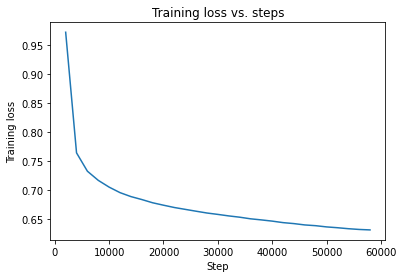

Saved: runs/m1_chem_tok_v1/plot_train_loss.png


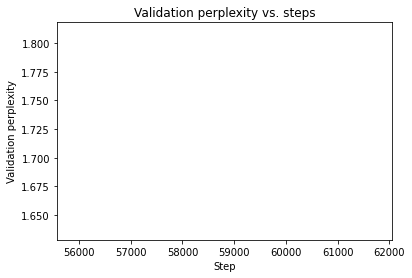

Saved: runs/m1_chem_tok_v1/plot_val_perplexity.png


In [13]:
# =========================
# Cell 6b — Evaluate on validation + plot loss/perplexity
# =========================
import math, matplotlib.pyplot as plt
import pandas as pd
from transformers import GPT2LMHeadModel

# Re-load the saved model (ensures we evaluate what’s on disk)
eval_model = GPT2LMHeadModel.from_pretrained(str(model_dir)).to(DEVICE)
trainer.model = eval_model

# Evaluate if we have a val set (from Cell 4b); otherwise skip
if 'val_ds_torch' in globals() and val_ds_torch is not None:
    eval_out  = trainer.evaluate()
    eval_loss = float(eval_out.get("eval_loss", float("nan")))
    eval_ppl  = math.exp(min(20.0, eval_loss)) if math.isfinite(eval_loss) else float("nan")
    print(f"Validation: eval_loss={eval_loss:.4f} | perplexity={eval_ppl:.2f}")
else:
    print("[info] No val_ds_torch provided; skipping validation.")

# Loss history (train)
hist = pd.DataFrame(getattr(trainer.state, "log_history", []))
if "loss" in hist.columns:
    loss_hist = hist[hist["loss"].notna()][["step","loss"]].reset_index(drop=True)
    plt.figure(); plt.plot(loss_hist["step"], loss_hist["loss"])
    plt.xlabel("Step"); plt.ylabel("Training loss"); plt.title("Training loss vs. steps")
    out_png = RUN_DIR / "plot_train_loss.png"; plt.savefig(out_png, bbox_inches="tight"); plt.show()
    print("Saved:", out_png)
else:
    print("[info] No per-step loss logs available in this transformers build.")

# If eval was logged during training (depends on version), also plot perplexity curve
if "eval_loss" in hist.columns:
    eval_hist = hist[hist["eval_loss"].notna()][["step","eval_loss"]].reset_index(drop=True)
    if not eval_hist.empty:
        eval_hist["perplexity"] = eval_hist["eval_loss"].clip(upper=20.0).apply(math.exp)
        plt.figure(); plt.plot(eval_hist["step"], eval_hist["perplexity"])
        plt.xlabel("Step"); plt.ylabel("Validation perplexity"); plt.title("Validation perplexity vs. steps")
        out_png = RUN_DIR / "plot_val_perplexity.png"; plt.savefig(out_png, bbox_inches="tight"); plt.show()
        print("Saved:", out_png)


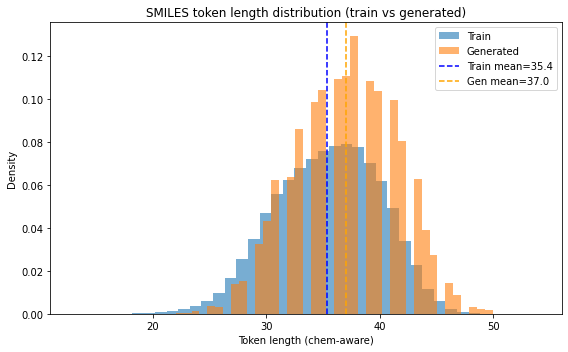

Saved: runs/m1_chem_tok_v1/plot_len_dist.png


In [16]:
# =========================
# Cell X — Token length distribution
# =========================
import matplotlib.pyplot as plt

# 1. Training distribution (chem-aware tokens)
train_tok_lens = [len(chem_tokenize(s)) for s in train_df["smiles"]]

# 2. Generated distribution
gen_tok_lens = [len(chem_tokenize(s)) for s in samples]

# 3. Plot side-by-side histograms
plt.figure(figsize=(8,5))
plt.hist(train_tok_lens, bins=40, alpha=0.6, label="Train", density=True)
plt.hist(gen_tok_lens, bins=40, alpha=0.6, label="Generated", density=True)
plt.axvline(np.mean(train_tok_lens), color="blue", linestyle="--", label=f"Train mean={np.mean(train_tok_lens):.1f}")
plt.axvline(np.mean(gen_tok_lens), color="orange", linestyle="--", label=f"Gen mean={np.mean(gen_tok_lens):.1f}")
plt.xlabel("Token length (chem-aware)")
plt.ylabel("Density")
plt.title("SMILES token length distribution (train vs generated)")
plt.legend()
plt.tight_layout()

out_png = RUN_DIR / "plot_len_dist.png"
plt.savefig(out_png, bbox_inches="tight")
plt.show()
print("Saved:", out_png)


In [7]:
# =========================
# Cell 6 — Train only if needed (robust skip/promote)
# =========================
from transformers import TrainingArguments, Trainer, GPT2LMHeadModel
import transformers, json, shutil
transformers.utils.logging.set_verbosity_error()

def final_model_present(path):
    return (path / "pytorch_model.bin").exists() or (path / "model.safetensors").exists()

def latest_checkpoint(path):
    if not path.exists():
        return None
    cks = [p for p in path.glob("checkpoint-*") if p.is_dir()]
    return sorted(cks, key=lambda p: int(p.name.split("-")[-1]))[-1] if cks else None

checkpoints_dir = RUN_DIR / "checkpoints"
final_exists = final_model_present(model_dir)
last_ckpt = latest_checkpoint(checkpoints_dir)

# --- hard override switches ---
FORCE_SKIP  = True   # <- set True to always skip training if we can load weights
AUTO_RESUME = False  # <- set True ONLY if you want to continue an interrupted first run

if final_exists:
    print("Training skipped: final model already exists at", model_dir)
    train_result = type("obj", (), {"metrics": {}})()

elif last_ckpt is not None and FORCE_SKIP:
    # Promote latest checkpoint to final model without training
    print("Final model not found, but checkpoint exists.")
    print("Promoting", last_ckpt.name, "->", model_dir, "(no training).")
    # load from checkpoint then save into model_dir
    tmp_model = GPT2LMHeadModel.from_pretrained(str(last_ckpt)).to(DEVICE)
    tmp_model.save_pretrained(str(model_dir))
    del tmp_model
    train_result = type("obj", (), {"metrics": {"promoted_from": last_ckpt.name}})()
    print("Saved final model ->", model_dir)

else:
    # True first train (or you explicitly want to resume)
    if last_ckpt is not None and AUTO_RESUME:
        print("Resuming training from:", last_ckpt)
        resume_from = str(last_ckpt)
    else:
        resume_from = None
        print("Starting training from scratch.")

    # dataset (chem tokens + randomized SMILES)
    train_ds_torch = SmilesTokenDataset(
        train_df, ctok, rand_prob=CONFIG["train"].get("smiles_randomize_prob", 0.7)
    )

    args = TrainingArguments(
        output_dir=str(checkpoints_dir),
        learning_rate=CONFIG["train"]["lr"],
        weight_decay=CONFIG["train"]["weight_decay"],
        warmup_steps=1000,
        per_device_train_batch_size=CONFIG["train"]["per_device_batch"],
        gradient_accumulation_steps=CONFIG["train"]["grad_accum"],
        fp16=CONFIG["train"]["fp16"] and torch.cuda.is_available(),
        logging_strategy="steps",
        logging_steps=2000,
        save_strategy="steps",
        save_steps=5000,
        save_total_limit=3,
        num_train_epochs=CONFIG["train"]["epochs"],
        report_to=[],
        disable_tqdm=False,
        dataloader_num_workers=4,
        dataloader_pin_memory=True,
        optim="adamw_torch_fused" if torch.cuda.is_available() else "adamw_torch",
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_ds_torch,
        data_collator=causal_collate,
    )

    try:
        train_result = trainer.train(resume_from_checkpoint=resume_from) if resume_from else trainer.train()
    except ValueError as e:
        # torch<2.6 optimizer-state restriction: fallback to model-only resume
        if "torch.load" in str(e) or "CVE" in str(e):
            print("Optimizer state resume blocked. Falling back to model-only resume.")
            if resume_from:
                model = GPT2LMHeadModel.from_pretrained(resume_from).to(DEVICE)
                trainer.model = model
            train_result = trainer.train()
        else:
            raise

    trainer.save_model(str(model_dir))
    with open(RUN_DIR / "train_result.json", "w") as f:
        json.dump(getattr(train_result, "metrics", {}), f, indent=2)
    print("Saved final model ->", model_dir)


Detected kernel version 4.18.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


Starting training from scratch.


Step,Training Loss
2000,0.974600
4000,0.764900
6000,0.733700
8000,0.717200


KeyboardInterrupt: 

In [14]:
# =========================
# Cell 7 — Sampling (robust to context length)
# =========================
import time, math
import pandas as pd
import torch
from tqdm.auto import tqdm
from transformers import GPT2LMHeadModel

# (Re)load model & read its limits
model = GPT2LMHeadModel.from_pretrained(str(model_dir)).to(DEVICE)
mconf = model.config

bos_id = mconf.bos_token_id if mconf.bos_token_id is not None else 1
eos_id = mconf.eos_token_id if mconf.eos_token_id is not None else bos_id

# model's max context (positional embeddings)
model_max_ctx = int(getattr(mconf, "n_positions", getattr(mconf, "n_ctx", ctok.max_length)))
print(f"Model context (n_positions): {model_max_ctx}")

@torch.inference_mode()
def sample_molecules_batched(
    model, tok, n=5000, batch_size=64, top_p=0.95, temperature=1.0, req_max_len=128
):
    model.eval().to(DEVICE)
    out = []
    # NEVER exceed model's context window
    max_len = min(int(req_max_len), model_max_ctx)
    if max_len < req_max_len:
        print(f"[info] Requested max_length={req_max_len} but model supports {model_max_ctx}. "
              f"Clamping to {max_len}.")

    num_batches = math.ceil(n / batch_size)
    for _ in tqdm(range(num_batches), desc="Sampling"):
        bsz = min(batch_size, n - len(out))
        bos = torch.full((bsz, 1), bos_id, device=DEVICE, dtype=torch.long)
        gen = model.generate(
            input_ids=bos,
            max_length=max_len,
            do_sample=True,
            top_p=top_p,
            temperature=temperature,
            pad_token_id=eos_id,
            eos_token_id=eos_id,
        ).tolist()
        out.extend(tok.decode(seq, skip_special_tokens=True) for seq in gen)
    return out[:n]

SAMP = CONFIG["sampling"]
samples = sample_molecules_batched(
    model, ctok,
    n=SAMP["n"],
    batch_size=64,
    top_p=SAMP["top_p"],
    temperature=SAMP["temperature"],
    req_max_len=SAMP["max_length"],  # will be clamped to model ctx
)

gen_path = RUN_DIR / f"generated_{int(time.time())}.smi"
pd.DataFrame({"smiles": samples}).to_csv(gen_path, index=False, header=False)
print("Saved samples ->", gen_path, "| count:", len(samples))


Model context (n_positions): 53
[info] Requested max_length=128 but model supports 53. Clamping to 53.


Sampling:   0%|          | 0/79 [00:00<?, ?it/s]

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Saved samples -> runs/m1_chem_tok_v1/generated_1758287135.smi | count: 5000


In [15]:
# =========================
# Cell 8 — Eval (validity / uniqueness / novelty)
# =========================
from rdkit import Chem
import numpy as np, json

def canon_or_none(s: str):
    try:
        m = Chem.MolFromSmiles(s, sanitize=True)
        if m is None: return None
        return Chem.MolToSmiles(m, isomericSmiles=True, canonical=True)
    except Exception:
        return None

# load the last generated file if 'samples' is not in memory
if 'samples' not in globals():
    latest = sorted(RUN_DIR.glob("generated_*.smi"))[-1]
    samples = [l.strip() for l in open(latest) if l.strip()]

valid_canon = [c for c in map(canon_or_none, samples) if c is not None]
train_set_canon = set(train_df["smiles"].tolist())

validity = len(valid_canon) / max(1, len(samples))
unique_valid = len(set(valid_canon))
uniqueness = unique_valid / max(1, len(valid_canon))
novel = sum(1 for s in set(valid_canon) if s not in train_set_canon)
novelty = novel / max(1, unique_valid)

metrics = {
    "n_samples": len(samples),
    "n_valid": len(valid_canon),
    "validity": round(validity, 4),
    "uniqueness_among_valid": round(uniqueness, 4),
    "novelty_vs_train": round(novelty, 4),
}

# write canonical valid unique set
valid_unique = sorted(set(valid_canon))
valid_path = RUN_DIR / "generated_valid_unique.smi"
with open(valid_path, "w") as f:
    for s in valid_unique:
        f.write(s + "\n")

with open(RUN_DIR / "metrics_basic.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("Saved:")
print(" - valid unique SMILES ->", valid_path, f"({len(valid_unique):,})")
print(" - metrics ->", RUN_DIR / "metrics_basic.json")
print(json.dumps(metrics, indent=2))


[09:05:35] Can't kekulize mol.  Unkekulized atoms: 0 2 3 4 13 14 15 17 18
[09:05:35] Can't kekulize mol.  Unkekulized atoms: 8 9 11 12 16 17 21
[09:05:35] Can't kekulize mol.  Unkekulized atoms: 10 19 22
[09:05:35] Can't kekulize mol.  Unkekulized atoms: 8 9 15
[09:05:35] SMILES Parse Error: unclosed ring for input: 'c1ccc(NC(NC2CC3CC2C2C(OC(=O)C=3C2)O1)=O)cc1'
[09:05:35] SMILES Parse Error: extra close parentheses while parsing: C(C(=O)NC1CCCC1)CCn1ncc(N)c1)=O
[09:05:35] SMILES Parse Error: check for mistakes around position 29:
[09:05:35] C1CCCC1)CCn1ncc(N)c1)=O
[09:05:35] ~~~~~~~~~~~~~~~~~~~~^
[09:05:35] SMILES Parse Error: Failed parsing SMILES 'C(C(=O)NC1CCCC1)CCn1ncc(N)c1)=O' for input: 'C(C(=O)NC1CCCC1)CCn1ncc(N)c1)=O'
[09:05:35] Can't kekulize mol.  Unkekulized atoms: 0 1 13 14 15
[09:05:35] SMILES Parse Error: extra close parentheses while parsing: c1c(cccc1)-c1c(C(OCC)=O)c(N)on1)C(=O)OCC
[09:05:35] SMILES Parse Error: check for mistakes around position 32:
[09:05:35] c1c(C(OC

Saved:
 - valid unique SMILES -> runs/m1_chem_tok_v1/generated_valid_unique.smi (4,986)
 - metrics -> runs/m1_chem_tok_v1/metrics_basic.json
{
  "n_samples": 5000,
  "n_valid": 4988,
  "validity": 0.9976,
  "uniqueness_among_valid": 0.9996,
  "novelty_vs_train": 0.8231
}


In [14]:
from rdkit import Chem
import numpy as np, pandas as pd

# lengths on valid, unique canon SMILES you saved
valid_unique = [l.strip() for l in open(RUN_DIR / "generated_valid_unique.smi").read().splitlines() if l.strip()]

lens = pd.Series([len(s) for s in valid_unique])
print(lens.describe(percentiles=[.5,.9,.95,.99]))
print("<=5 chars:", (lens<=5).mean(), "| <=8 chars:", (lens<=8).mean())


count    4988.000000
mean       36.081796
std         4.419469
min        20.000000
50%        36.000000
90%        42.000000
95%        43.000000
99%        46.000000
max        51.000000
dtype: float64
<=5 chars: 0.0 | <=8 chars: 0.0


In [15]:
from rdkit.Chem import Descriptors

def props(smiles):
    m = Chem.MolFromSmiles(smiles)
    if m is None: return None
    return Descriptors.MolWt(m), Descriptors.MolLogP(m)

gen_props = [props(s) for s in valid_unique]
gen_props = pd.DataFrame([p for p in gen_props if p is not None], columns=["MW","logP"])

train_props = [props(s) for s in train_df["smiles"].tolist()]
train_props = pd.DataFrame([p for p in train_props if p is not None], columns=["MW","logP"]).sample(min(20000, len(train_df)), random_state=0)

print("Generated MW/logP:\n", gen_props.describe())
print("\nTrain MW/logP:\n", train_props.describe())


Generated MW/logP:
                 MW         logP
count  4988.000000  4988.000000
mean    307.537875     2.458468
std      27.493935     0.912053
min     212.293000    -2.223500
25%     287.359000     1.902035
50%     310.359500     2.550760
75%     329.389000     3.102360
max     374.510000     5.076440

Train MW/logP:
                  MW          logP
count  20000.000000  20000.000000
mean     307.252842      2.444163
std       28.031341      0.932994
min      250.172000     -3.851400
25%      284.381000      1.872655
50%      310.397000      2.564820
75%      331.460000      3.127685
max      349.906000      4.711900


In [16]:
allowed_atoms = set("CNOFSclBrI")  # halogens lowercase for smiles; Rdkit canonical may use uppercase for Br/Cl
def approx_filter_ok(s):
    m = Chem.MolFromSmiles(s)
    if m is None: return False
    # atom set
    for a in m.GetAtoms():
        sym = a.GetSymbol()
        if sym not in {"C","N","O","S","F","Cl","Br"}:  # simple set
            return False
        if a.GetFormalCharge() != 0:
            return False
    # ring size <= 8
    sssr = Chem.GetSymmSSSR(m)
    if any(len(r) > 8 for r in sssr):
        return False
    return True

approx_pass = sum(1 for s in valid_unique if approx_filter_ok(s))
print("Approx MOSES filter pass rate:", approx_pass/len(valid_unique))


Approx MOSES filter pass rate: 1.0


In [17]:
samples_30k = sample_molecules_batched(model, ctok, n=30000, batch_size=64,
                                       top_p=CONFIG["sampling"]["top_p"],
                                       temperature=CONFIG["sampling"]["temperature"],
                                       max_length=CONFIG["sampling"]["max_length"],
                                       device=DEVICE)
# recompute validity/uniqueness/novelty on 30k
def canon_or_none(s):
    try:
        m = Chem.MolFromSmiles(s, sanitize=True)
        if m is None: return None
        return Chem.MolToSmiles(m, isomericSmiles=True, canonical=True)
    except Exception:
        return None

valid_canon = [c for c in map(canon_or_none, samples_30k) if c is not None]
validity = len(valid_canon)/len(samples_30k)
unique_valid = len(set(valid_canon))
uniqueness = unique_valid/len(valid_canon)
train_set_canon = set(train_df["smiles"].tolist())
novel = sum(1 for s in set(valid_canon) if s not in train_set_canon)
novelty = novel/unique_valid
print({"validity":round(validity,4), "uniqueness":round(uniqueness,4), "novelty":round(novelty,4)})


Sampling:   0%|          | 0/469 [00:00<?, ?it/s]

[21:56:41] Can't kekulize mol.  Unkekulized atoms: 5 6 7 9 10 11 12 16 17 18 19
[21:56:41] Can't kekulize mol.  Unkekulized atoms: 2 3 11
[21:56:41] SMILES Parse Error: unclosed ring for input: 'CC(C)(C)c1ccc(C(=O)CC2(O)C(=O)N(CC(N)=O)c3ccccc32)cc'
[21:56:41] SMILES Parse Error: unclosed ring for input: 'O=C(CC1CCCCC1)N1CCN(c2nc3nonc3nc2NC2)CC1'
[21:56:41] SMILES Parse Error: unclosed ring for input: 'CC(NC(=O)C(NC(=O)c1ccccc1Cl)C(C)C)C(C)N1CCOC'
[21:56:41] SMILES Parse Error: unclosed ring for input: 'Cc1ccc(N2CCC3C(CCC(=O)N3CCOCC3)C2)nn1'
[21:56:42] SMILES Parse Error: unclosed ring for input: 'CC1(C)Cc2nc3n(c(=O)c2COc2ccccc2)CCS3(=O)=O'
[21:56:42] Can't kekulize mol.  Unkekulized atoms: 4 5 6 8 9 10 11 12 17
[21:56:42] Can't kekulize mol.  Unkekulized atoms: 6 7 9 10 14 15 16
[21:56:42] Can't kekulize mol.  Unkekulized atoms: 8 9 11 12 14 16 17
[21:56:42] Can't kekulize mol.  Unkekulized atoms: 4 5 6 8 9 21 22
[21:56:42] Can't kekulize mol.  Unkekulized atoms: 3 4 20
[21:56:42] SMIL

{'validity': 0.9983, 'uniqueness': 0.9952, 'novelty': 0.7684}
